In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('../data/customer_churn.csv')

df.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    str    
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    str    
 7   Location         900 non-null    str    
 8   Company          900 non-null    str    
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 70.4 KB


In [6]:
df.isnull().sum()

Names              0
Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Onboard_date       0
Location           0
Company            0
Churn              0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    str    
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    str    
 7   Location         900 non-null    str    
 8   Company          900 non-null    str    
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 70.4 KB


In [9]:
df['Onboard_date'] = pd.to_datetime(df['Onboard_date'], format='mixed', dayfirst=True)

df['Onboard_date'].dtype

dtype('<M8[us]')

we need an understand of the tenure of the customer in years as New, mid and old

In [10]:
df['Tenure_years'] = pd.cut(df['Years'], bins=[0,3,5,10], labels=['New', "mid", 'Old'])

df.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,Tenure_years
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,Old
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,Old
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,Old


In [11]:
df['Tenure_years'].value_counts()

Tenure_years
Old    519
mid    339
New     42
Name: count, dtype: int64

In [12]:
df['Churn'].value_counts()

Churn
0    750
1    150
Name: count, dtype: int64

In [13]:
df.groupby('Years')['Churn'].mean().sort_values(ascending=False)

Years
8.97    1.0
7.84    1.0
7.80    1.0
7.76    1.0
7.61    1.0
       ... 
7.60    0.0
7.59    0.0
3.00    0.0
2.99    0.0
2.17    0.0
Name: Churn, Length: 418, dtype: float64

In [14]:
df.groupby('Num_Sites')['Churn'].mean().sort_values(ascending=False)

Num_Sites
13.0    1.000000
12.0    0.843750
14.0    0.833333
11.0    0.554217
10.0    0.259542
9.0     0.102151
8.0     0.037559
6.0     0.014925
7.0     0.013699
5.0     0.000000
3.0     0.000000
4.0     0.000000
Name: Churn, dtype: float64

we need strong predictor so we make an interaction feature

In [15]:
df['Year_Num_sites'] = df['Years'] * df['Num_Sites']

df.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,Tenure_years,Year_Num_sites
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,Old,57.76
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,Old,71.50
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,Old,80.04


The value of the Total purchase is in very high number so we need to make normalize it so that it can be easy for the machine to learn. we are going to use transformation feature

In [16]:
df['Log_Total_Purchase'] = np.log1p(df['Total_Purchase'])

df.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,Tenure_years,Year_Num_sites,Log_Total_Purchase
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,Old,57.76,9.311795
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,Old,71.50,9.385740
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,Old,80.04,9.463877


Now we add polynomial feature so the machine can also learn from non linear data

In [17]:
df['Sqrd_years'] = df['Years'] ** 2

df.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,Tenure_years,Year_Num_sites,Log_Total_Purchase,Sqrd_years
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,Old,57.76,9.311795,52.1284
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,Old,71.50,9.385740,42.2500
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,Old,80.04,9.463877,44.4889


All features done and we also checked for data leakage and found none.

In [18]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Churn,Year_Num_sites,Log_Total_Purchase,Sqrd_years
count,900.000000,900.000000,900.000000,900.000000,900.000000,900,900.000000,900.000000,900.000000,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,2011-04-16 22:35:36.358888,0.166667,45.400711,9.181865,29.428585
min,22.000000,100.000000,0.000000,1.000000,3.000000,2006-01-03 07:20:00,0.000000,10.000000,4.615121,1.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,2008-06-29 16:05:08,0.000000,34.930000,9.047600,19.802500
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,2011-03-26 09:29:36.500000,0.000000,43.910000,9.215016,27.196250
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,2014-02-24 19:50:14.750000,0.000000,53.470000,9.372553,37.332100
max,65.000000,18026.010000,1.000000,9.150000,14.000000,2016-12-28 04:07:38,1.000000,101.500000,9.799626,83.722500
std,6.127560,2408.644532,0.499921,1.274449,1.764836,NaN,0.372885,15.084907,0.298455,13.662527


we will look for the outliers

<Axes: xlabel='Total_Purchase', ylabel='Count'>

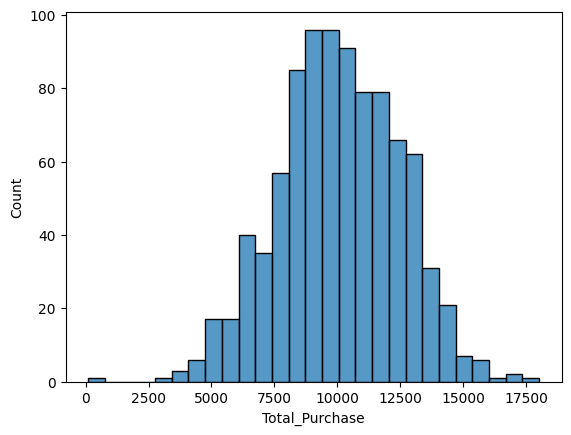

In [19]:
sns.histplot(df['Total_Purchase'])

we have found one and we will check if its a mistake entry or very small that can disturb the learning. if so we will be removing it

In [20]:
df.sort_values(by='Total_Purchase', ascending=True).head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,Tenure_years,Year_Num_sites,Log_Total_Purchase,Sqrd_years
659,Kayla Reeves,38.0,100.00,0,5.27,5.0,2006-03-10 09:01:48,"1511 Porter Drive Amberberg, NC 44608",Stewart-Lopez,0,Old,26.35,4.615121,27.7729
371,Justin Campos,53.0,3263.00,1,2.77,9.0,2013-11-11 22:49:58,"3483 Davis Viaduct Guzmanmouth, RI 60858",Hall-Butler,0,New,24.93,8.090709,7.6729
448,Lori Medina,39.0,3676.68,1,3.52,9.0,2008-07-16 11:36:45,"PSC 1874, Box 9238 APO AP 68299","Garcia, Hansen and Austin",0,mid,31.68,8.210037,12.3904


purchase value seems too low but not a mistake one. But we will remove this outliers so that we can have balance data.

In [21]:
df = df.drop(659)



<Axes: xlabel='Total_Purchase', ylabel='Count'>

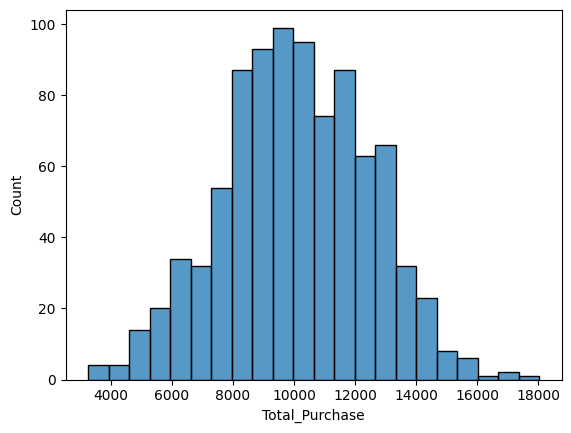

In [22]:
sns.histplot(df['Total_Purchase'])

In [23]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Churn,Year_Num_sites,Log_Total_Purchase,Sqrd_years
count,899.000000,899.000000,899.000000,899.000000,899.000000,899,899.000000,899.000000,899.000000,899.000000
mean,41.820912,10073.906151,0.481646,5.273159,8.591769,2011-04-19 00:20:37.614015,0.166852,45.421902,9.186944,29.430427
min,22.000000,3263.000000,0.000000,1.000000,3.000000,2006-01-03 07:20:00,0.000000,10.000000,8.090709,1.000000
25%,38.000000,8508.135000,0.000000,4.450000,7.000000,2008-07-01 19:32:54.500000,0.000000,34.965000,9.048895,19.802500
50%,42.000000,10050.610000,0.000000,5.210000,8.000000,2011-03-28 01:58:13,0.000000,43.920000,9.215488,27.144100
75%,46.000000,11761.520000,1.000000,6.110000,10.000000,2014-02-24 22:13:10.500000,0.000000,53.480000,9.372673,37.332100
max,65.000000,18026.010000,1.000000,9.150000,14.000000,2016-12-28 04:07:38,1.000000,101.500000,9.799626,83.722500
std,6.129647,2386.917245,0.499941,1.275158,1.761750,NaN,0.373051,15.079895,0.256758,13.670021


<Axes: xlabel='Age', ylabel='Count'>

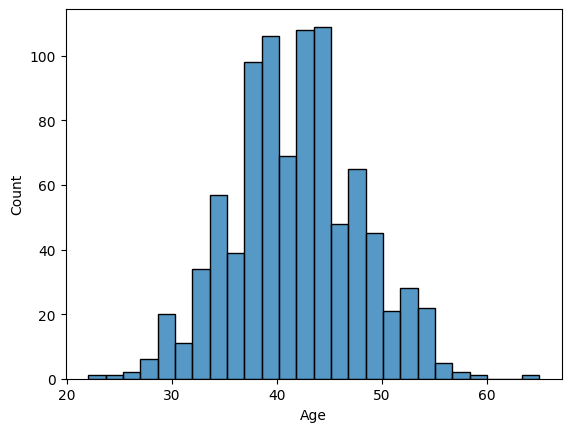

In [24]:
sns.histplot(df['Age'])

Data of the Age seems fine. we are done with the cleaning our data.

Now we will done the feature splitting

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X = df.drop('Churn', axis=1)

In [27]:
y = df['Churn']

In [28]:
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (899, 13)
y shape: (899,)


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=.2,
    random_state=42
)

In [30]:
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (719, 13)
X_test: (180, 13)
y_train: (719,)
y_test: (180,)


Test and train sets are ready not we will work on the pipeline  

We will start with the features and then preprocessor before making the pipeline.

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler 
from sklearn.preprocessing import OneHotEncoder

In [32]:
df.head(2)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,Tenure_years,Year_Num_sites,Log_Total_Purchase,Sqrd_years
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,Old,57.76,9.311795,52.1284
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,Old,71.50,9.385740,42.2500


In [33]:
numeric_features = [
    'Age',
    'Total_Purchase',
    'Years',
    'Num_Sites',
    'Year_Num_sites',
    'Log_Total_Purchase',
    'Sqrd_years'
]

catergorical_features = [
    'Account_Manager',
    'Tenure_years',
]

Now we make the preprocessor

In [34]:
prepro = ColumnTransformer(
    transformers=[(
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(drop='if_binary'),
            catergorical_features
        )
    ]
)

preprocessor is done we will make the pipeline and start with logistic regression


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [36]:
lrpp = Pipeline([
    ('preprocessor', prepro),
    ('model',LogisticRegression())
])

In [37]:
lrpp.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [38]:
lr_pred = lrpp.predict(X_test)

In [39]:
print("classification report for Logistic regression: \n", classification_report(y_test, lr_pred))

classification report for Logistic regression: 
               precision    recall  f1-score   support

           0       0.92      0.95      0.93       148
           1       0.73      0.59      0.66        32

    accuracy                           0.89       180
   macro avg       0.82      0.77      0.79       180
weighted avg       0.88      0.89      0.88       180



Now we check thru Random Forrest classifier


In [40]:
from sklearn.ensemble import RandomForestClassifier

In [41]:
RFCpp = Pipeline([
    ('preprocessor', prepro),
    ('model',RandomForestClassifier(random_state=42))
])

In [42]:
RFCpp.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [43]:
RFC_pred = RFCpp.predict(X_test)

In [44]:
print('Classification report from Randomforrest Classifier\n', classification_report(y_test, RFC_pred))

Classification report from Randomforrest Classifier
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       148
           1       0.74      0.44      0.55        32

    accuracy                           0.87       180
   macro avg       0.81      0.70      0.74       180
weighted avg       0.86      0.87      0.86       180



we will do a some hypermeter tuning to get more results using the GridsearchCV

In [45]:
from sklearn.model_selection import GridSearchCV

we need create parameters for the grid

In [46]:
param_grid = {
    "model__n_estimators":[50, 100, 200],
    "model__max_depth":[3,5,10,None]
}

In [47]:
RFC_Grid_pp = Pipeline([
    ('preprocessor', prepro),
    ('model', RandomForestClassifier(random_state=42))
])

In [48]:
RFC_Grid = GridSearchCV(
    RFC_Grid_pp,
    param_grid,
    cv=5,
    scoring='recall'
)

In [49]:
RFC_Grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [3, 5, ...], 'model__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is a

In [50]:
RFC_Grid_Pred = RFC_Grid.predict(X_test)

print('Best Parameter: ', RFC_Grid.best_params_)
print('Best Recall Score: ', RFC_Grid.best_score_)
print('classification report from RFC GridSearch Hypermeter tuning: \n', classification_report(y_test, RFC_Grid_Pred))

Best Parameter:  {'model__max_depth': 5, 'model__n_estimators': 100}
Best Recall Score:  0.5090579710144928
classification report from RFC GridSearch Hypermeter tuning: 
               precision    recall  f1-score   support

           0       0.88      0.97      0.92       148
           1       0.72      0.41      0.52        32

    accuracy                           0.87       180
   macro avg       0.80      0.69      0.72       180
weighted avg       0.85      0.87      0.85       180



we will now try with Gradient boosting classifier

In [51]:
from sklearn.ensemble import GradientBoostingClassifier

In [79]:
GBCpp = Pipeline([
    ('preprocessor', prepro),
    ('model', GradientBoostingClassifier(random_state=42))
])

In [80]:
GBCpp.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [81]:
GBC_Pred = GBCpp.predict(X_test)

print('classification report from Gradient Boosting Classifier: \n', classification_report(y_test, GBC_Pred))

classification report from Gradient Boosting Classifier: 
               precision    recall  f1-score   support

           0       0.90      0.95      0.92       148
           1       0.70      0.50      0.58        32

    accuracy                           0.87       180
   macro avg       0.80      0.73      0.75       180
weighted avg       0.86      0.87      0.86       180



now we do KNN classifier

In [55]:
from sklearn.neighbors import KNeighborsClassifier

In [56]:
KNNpp = Pipeline([
    ('preprpcessor', prepro),
    ('model', KNeighborsClassifier())
])

In [57]:
KNNpp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprpcessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [58]:
KNN_pred = KNNpp.predict(X_test)

print('classification report from KNN Classifier: \n', classification_report(y_test, KNN_pred))

classification report from KNN Classifier: 
               precision    recall  f1-score   support

           0       0.88      0.95      0.91       148
           1       0.63      0.38      0.47        32

    accuracy                           0.85       180
   macro avg       0.75      0.66      0.69       180
weighted avg       0.83      0.85      0.83       180



Now we do Xgboost

In [59]:
from xgboost import XGBClassifier

In [60]:
XGBpp = Pipeline([
    ('preprocessor', prepro),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric = 'logloss'
    ))
])

In [61]:
XGBpp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [62]:
XGB_pred = XGBpp.predict(X_test)

print('classification report from XGBoost: \n', classification_report(y_test, XGB_pred))


classification report from XGBoost: 
               precision    recall  f1-score   support

           0       0.89      0.94      0.91       148
           1       0.61      0.44      0.51        32

    accuracy                           0.85       180
   macro avg       0.75      0.69      0.71       180
weighted avg       0.84      0.85      0.84       180



In [63]:
XGB_param_grid = {
    'model__n_estimator':[50,100,200],
    'model__max_depth':[3,5,7],
    'model__learning_rate':[0.01,0.1,0.2]
}

In [64]:
XGB_Grid = GridSearchCV(
    XGBpp,
    XGB_param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

In [65]:
XGB_Grid.fit(X_train, y_train)

d:\advanced-data-wrangling-lab\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:36:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.1, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimator': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

In [66]:
XGBHP_pred = XGB_Grid.predict(X_test)

print('Best Parameter: ', XGB_Grid.best_params_)
print('Best Recall Score: ', XGB_Grid.best_score_)
print('classification report from RFC GridSearch Hypermeter tuning: \n', classification_report(y_test, XGBHP_pred))

Best Parameter:  {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimator': 50}
Best Recall Score:  0.5764492753623188
classification report from RFC GridSearch Hypermeter tuning: 
               precision    recall  f1-score   support

           0       0.90      0.95      0.92       148
           1       0.70      0.50      0.58        32

    accuracy                           0.87       180
   macro avg       0.80      0.73      0.75       180
weighted avg       0.86      0.87      0.86       180



Now Final Scores of the models and classifiers

In [94]:
from sklearn.model_selection import cross_val_score

In [95]:
lrscores = cross_val_score(
    lrpp,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)

In [96]:
RFscores = cross_val_score(
    RFCpp,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)

In [97]:
RFCHPscore = cross_val_score(
    RFC_Grid,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)

In [98]:
GBCscore = cross_val_score(
    GBCpp,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)

In [99]:
XGBscore = cross_val_score(
    XGBpp,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)

In [100]:
XGBHPscore = cross_val_score(
    XGB_Grid,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)

d:\advanced-data-wrangling-lab\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:58:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\advanced-data-wrangling-lab\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:58:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\advanced-data-wrangling-lab\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:58:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\advanced-data-wrangling-lab\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:58:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator" } are not use

In [101]:
KNNscore = cross_val_score(
    KNNpp,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)

In [102]:
print('\nLinear regression Score:\n ', lrscores)
print('\nRandom Forrest Classifier Score:\n ', RFscores)
print('\nRandom Forrest Classifier Hyperparameter tuned Score:\n ', RFCHPscore)
print('\nGradient Boosting Classifier Score:\n ', GBCscore)
print('\nXGBoost Score:\n ', XGBscore)
print('\nXGBoost Hyperparameter tuned Score:\n ', XGBHPscore)
print('\nKNN Score:\n ', KNNscore)


Linear regression Score:
  [0.56521739 0.58333333 0.45833333 0.54166667 0.52173913]

Random Forrest Classifier Score:
  [0.47826087 0.54166667 0.41666667 0.54166667 0.52173913]

Random Forrest Classifier Hyperparameter tuned Score:
  [0.43478261 0.54166667 0.375      0.5        0.52173913]

Gradient Boosting Classifier Score:
  [0.60869565 0.58333333 0.45833333 0.5        0.52173913]

XGBoost Score:
  [0.56521739 0.70833333 0.5        0.54166667 0.56521739]

XGBoost Hyperparameter tuned Score:
  [0.56521739 0.625      0.45833333 0.5        0.60869565]

KNN Score:
  [0.43478261 0.5        0.33333333 0.5        0.52173913]


Cross Validation is a model evaluation technique that measures how well a model generalizes by training and testing it across multiple data splits. GridSearchCV is a hyperparameter tuning technique that tries multiple parameter combinations and uses Cross Validation internally to identify the best-performing combination.

Cross Validation = Evaluate

GridSearchCV = Optimize + Evaluate

In [103]:
Recall_values = {
    'Models' :["LogisticRegression", 
               'RandomForestClassifier', 
               'RandomForestClassifier Hypermeter Tunning', 
               'GradientBoostingClassifier',
               'KNeighborsClassifier',
               'XGBClassifier',
               'XGBClassifier hypermeter tunning'],
    'Recall' :[.59,.44,.41,.50,.38,.44,.50]
}

Results = pd.DataFrame(Recall_values)

Results.sort_values('Recall', ascending=False)


,Models,Recall
0,LogisticRegression,0.59
6,XGBClassifier hypermeter tunning,0.50
3,GradientBoostingClassifier,0.50
5,XGBClassifier,0.44
1,RandomForestClassifier,0.44
2,RandomForestClassifier Hypermeter Tunning,0.41
4,KNeighborsClassifier,0.38
